# Fase 2: Inteligencia de Mercados Regionales
Objetivo: Entender el comportamiento del consumidor en $NA$ (Norteamérica), $EU$ (Europa) y $JP$ (Japón).
## Acciones:
    - Market Share: Cálculo del peso relativo de cada región sobre las ventas globales.
    - Preferencia de Género: Identificar por qué ciertos géneros (ej. RPG en Japón) dominan mercados específicos.
    - Dominio de Plataformas: Análisis de la penetración de hardware por región.
    - KPI: Ventas Totales por Región

Lo primero que haremos sera cargar nuestro dataset limpio en nuestro notebook. Al ser un archivo .parquet, este guarda los tipos de datos de las columnas, por lo que no habra que preocuparse por datos nulos o errores en los tipos.

In [1]:
### importamos dependencias
import pandas as pd
from pathlib import Path

# definimos la ruta
path = Path(r"C:\Users\antim\OneDrive\Escritorio\poryectos\proyecto_videojuegos\data\dataset_limpio.parquet")
path

WindowsPath('C:/Users/antim/OneDrive/Escritorio/poryectos/proyecto_videojuegos/data/dataset_limpio.parquet')

In [2]:
data = pd.read_parquet(path)

data.head(4)

,rank,name,platform,year,genre,publisher,na_sales,eu_sales,jp_sales,other_sales,global_sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00


## Una vez cargado nuestro dataset

Podemos empezar a con las tareas de anlisis.


1. El Pastel del Mercado (Market Share)
Queremos saber quién pone el dinero sobre la mesa.

    - Tu tarea: Calcula el total de ventas para na_sales, eu_sales, jp_sales y other_sales.

    > Pro-tip: No sumes global_sales para esto, suma las regiones individuales y compáralas.

    - Visualización: Crea un gráfico de tarta (plt.pie) o de barras para mostrar qué porcentaje del mercado mundial representa cada región.

2. El Choque Cultural: Norteamérica vs. Japón
Esta es la parte más reveladora. Históricamente, lo que triunfa en EE.UU. a veces fracasa en Japón y viceversa.

    - Tu tarea: Agrupa los datos por genre y suma las ventas de na_sales y jp_sales.

    - Visualización: Crea un gráfico de barras comparativo (puedes usar sns.barplot con el parámetro hue si transformas los datos, o dos gráficos uno al lado del otro con plt.subplots).

. Pregunta clave: ¿Qué género es el rey absoluto en Japón y cuál es el rey en Norteamérica?

3. Las Plataformas "Locales"
¿Es cierto que Nintendo y Sony dominan Japón mientras que Microsoft tiene más peso en Occidente?

    - Tu tarea: Encuentra el Top 3 de plataformas (consolas) con más ventas en cada una de las tres regiones principales.

### Empecemos con el punto 1, para lo cual haremos una suma de las ventas totales cada region. Para luego realizar un grafico de pastel.

In [3]:
total_ventas_por_region = data[['na_sales',	'eu_sales',	'jp_sales',	'other_sales']].sum()

display(total_ventas_por_region)

na_sales       4332.43
eu_sales       2408.88
jp_sales       1284.28
other_sales     788.89
dtype: float64

Ahora hagamos el grafico de pastel.
Para ello utilizaremos la libreria matplotlib.

In [18]:
!pip install matplotlib


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


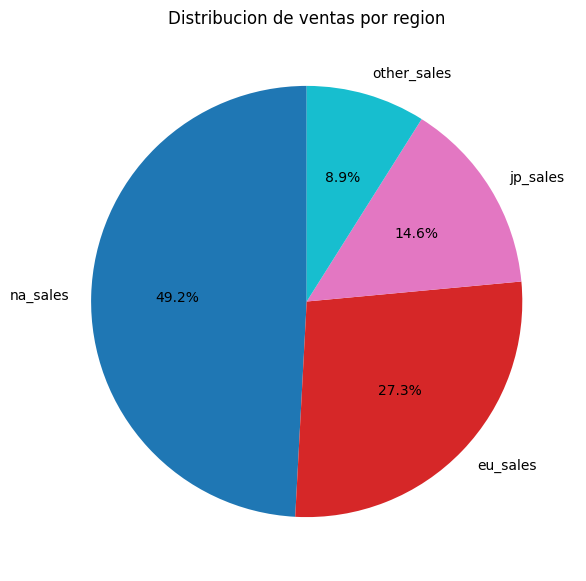

In [17]:
#importamos la dependencia
import matplotlib.pyplot as plt

# defininmos el size de la figura
plt.figure(figsize=(7,7))

# autopct='%1.1f%%' le dice a matplotlib que calcule y muestre los porcentajes
total_ventas_por_region.plot(kind='pie', autopct='%1.1f%%', startangle=90, 
                             cmap='tab10')
# definimos un titulo
plt.title("Distribucion de ventas por region")
#ocultamos la etiqueta del eje y
plt.ylabel('')
# mostrmaos el grafico
plt.show()

### 2. El Choque Cultural: Norteamérica vs. Japón.

Esta es la parte más reveladora. Históricamente, lo que triunfa en EE.UU. a veces fracasa en Japón y viceversa.

- Tu tarea: Agrupa los datos por genre y suma las ventas de na_sales y jp_sales.

- Visualización: Crea un gráfico de barras comparativo (puedes usar sns.barplot con el parámetro hue si transformas los datos, o dos gráficos uno al lado del otro con plt.subplots).

- Pregunta clave: ¿Qué género es el rey absoluto en Japón y cuál es el rey en Norteamérica?

In [19]:
# utilizamos el metodo groupby
ventas_genre_na_jp = data.groupby('genre')[['na_sales', 'jp_sales']].sum()

display(ventas_genre_na_jp)

,na_sales,jp_sales
genre,,
Action,861.80,158.66
Adventure,102.06,52.01
Fighting,220.74,87.15
Misc,402.48,106.67
Platform,445.99,130.65
Puzzle,122.01,56.68
Racing,355.93,56.59
Role-Playing,326.50,350.29
Shooter,575.16,38.18


In [ ]:
# asignamos la cantidad de graficos
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6)) # axes seran los espacios del grafico

# autopct='%1.1f%%' le dice a matplotlib que calcule y muestre los porcentajes
total_ventas_por_region.plot(kind='pie', autopct='%1.1f%%', startangle=90, 
                             cmap='tab10')
# definimos un titulo
plt.title("Distribucion de ventas por region")
#ocultamos la etiqueta del eje y
plt.ylabel('')
# mostrmaos el grafico
plt.show()

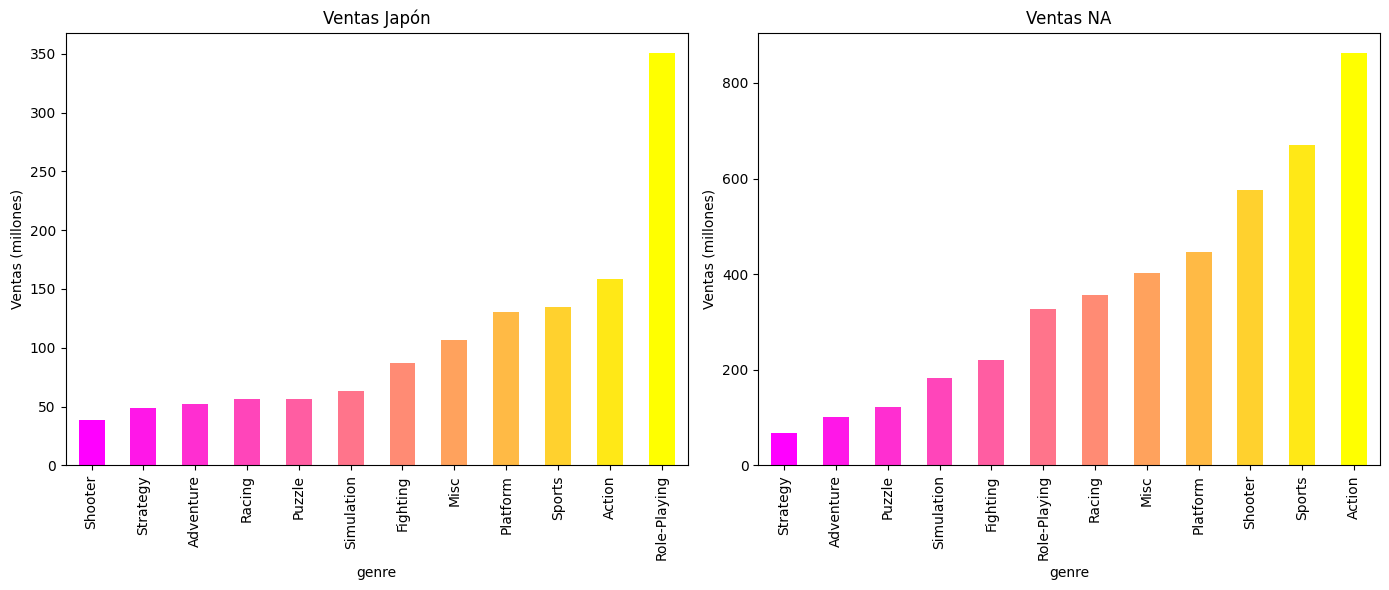

<Figure size 640x480 with 0 Axes>

In [35]:
# importamso numpy lo utilizaremospara los colores del grafico
import numpy as np

# primero ordenamos los datos
jp_sorted = ventas_genre_na_jp['jp_sales'].sort_values()
na_sorted = ventas_genre_na_jp['na_sales'].sort_values()

# Creamos colores según el tamaño correcto
colores = plt.cm.spring(np.linspace(0, 1, len(jp_sorted)))

# 1. Crear el lienzo (fig) y los recuadros (axes)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# 'axes' ahora es una lista con dos espacios: axes[0] y axes[1]

# Plot JP
jp_sorted.plot(kind='bar', color=colores, ax=axes[0])
axes[0].set_title('Ventas Japón')
axes[0].set_ylabel('Ventas (millones)')

# Plot NA
na_sorted.plot(kind='bar', color=colores, ax=axes[1])
axes[1].set_title('Ventas NA')
axes[1].set_ylabel('Ventas (millones)')

plt.tight_layout()
plt.show()

# 4. Ajustar el espaciado para que nada se superponga
plt.tight_layout()

# 5. Mostrar la figura completa
plt.show()